In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("fleet_project_datasets_fixed.csv")

In [3]:
df.head()

,vehicle_id,make,model,year,vehicle_type,capacity_kg,purchase_date,current_mileage_km,fuel_efficiency_km_l,annual_maintenance_cost,driver_performance_score,vechicle_age,cost_per_km,monthly_milegade,vechicle_age_month,monthlt_milegade,Efficiency category
0,VEH1000,Isuzu,ModelA,2010,Trailer,13234,2022-06-17,824724,4.4,3154.69,64,41,0.0038,1676.2683,492,1676.268293,Low
1,VEH1001,Volvo,ModelE,2017,Van,19290,2018-05-14,312114,8.4,1671.87,77,90,0.0054,288.9944,1080,288.994444,Low
2,VEH1002,MAN,ModelD,2023,Van,7254,2023-08-03,69279,8.8,962.02,87,27,0.0139,213.8241,324,213.824074,Low
3,VEH1003,Isuzu,ModelD,2023,Van,18144,2023-12-11,63946,12.5,1085.36,81,23,0.0170,231.6884,276,231.688406,Medium
4,VEH1004,Toyota,ModelD,2021,Van,8350,2021-04-27,92481,11.0,1039.38,80,55,0.0112,140.1227,660,140.122727,Medium


In [4]:
# Ensure purchase_date is datetime
df['purchase_date']=pd.to_datetime(df['purchase_date'], errors='coerce')
anomalies = {}

#missing values
anomalies["missing_values"]=df.isna().sum()

#dupliacte row
anomalies['duplicate_rows']=df.duplicated().sum()

anomalies['negative_mileage'] = df[df['current_mileage_km'] < 0]
anomalies['negative_fuel_efficiency'] = df[df['fuel_efficiency_km_l'] < 0]
anomalies['negative_capacity'] = df[df['capacity_kg'] < 0]
anomalies['negative_maintenance_cost'] = df[df['annual_maintenance_cost'] < 0]


In [5]:
#year anomalies
anomalies['year']=df[(df['year']<1980) | (df['year']>2025)]

# future purchase date
anomalies['future_purchase']=df[df['purchase_date']>pd.Timestamp.today()]

for key, value in anomalies.items():

    # Missing values → pandas Series
    if isinstance(value, pd.Series):
        print(f"\n{key}:\n{value}")

    # Duplicates → integer
    elif isinstance(value, (int, np.integer)):
        print(f"\n{key}: {value}")

    # Anomaly DataFrames
    else:
        print(f"\n{key}: {len(value)} rows")


missing_values:
vehicle_id                  0
make                        0
model                       0
year                        0
vehicle_type                0
capacity_kg                 0
purchase_date               0
current_mileage_km          0
fuel_efficiency_km_l        0
annual_maintenance_cost     0
driver_performance_score    0
vechicle_age                0
cost_per_km                 0
monthly_milegade            0
vechicle_age_month          0
monthlt_milegade            0
Efficiency category         0
dtype: int64

duplicate_rows: 0

negative_mileage: 0 rows

negative_fuel_efficiency: 0 rows

negative_capacity: 0 rows

negative_maintenance_cost: 0 rows

year: 0 rows

future_purchase: 0 rows


In [6]:
# FIXING DATA TYPES

df['purchase_date']=pd.to_datetime(df['purchase_date'], errors='coerce')

In [7]:
numeric_col=df.select_dtypes(include=['number']).columns
for col in numeric_col:
    df[col]=pd.to_numeric(df[col], errors='coerce')

# Standardize text fields
cat_col=df.select_dtypes(exclude=['number']).columns

for col in cat_col:
    df[col]=df[col].astype(str).str.strip().str.title()

print("\n=== Data Types Fixed ===")
print(df.dtypes)



=== Data Types Fixed ===
vehicle_id                   object
make                         object
model                        object
year                          int64
vehicle_type                 object
capacity_kg                   int64
purchase_date                object
current_mileage_km            int64
fuel_efficiency_km_l        float64
annual_maintenance_cost     float64
driver_performance_score      int64
vechicle_age                  int64
cost_per_km                 float64
monthly_milegade            float64
vechicle_age_month            int64
monthlt_milegade            float64
Efficiency category          object
dtype: object


In [8]:
# VALIDATING RANGES
df['year'].max()
validation_issue={}

validation_issue['invalid_year'] = df[(df['year'] < 2010) | (df['year'] > 2030)]

# Mileage must be positive
validation_issue['invalid_mileage']=df[df['current_mileage_km']<=0]

# Capacity must be positive
validation_issue['invalid_capacity']=df[df['capacity_kg']<=0]

# Fuel efficiency must be positive
validation_issue['invalid_fuel_efficiency'] = df[df['fuel_efficiency_km_l'] <= 0]

# Maintenance cost cannot be negative
validation_issue['invalid_maintenance_cost'] = df[df['annual_maintenance_cost'] < 0]

# Driver score should be between 0–100 (assumption)
validation_issue['invalid_driver_score'] = df[(df['driver_performance_score'] < 0) |
                                               (df['driver_performance_score'] > 100)]


print("\n=== Validation Results ===")
for key, value in validation_issue.items():
    print(f"{key}: {len(value)} rows")



=== Validation Results ===
invalid_year: 0 rows
invalid_mileage: 0 rows
invalid_capacity: 0 rows
invalid_fuel_efficiency: 0 rows
invalid_maintenance_cost: 0 rows
invalid_driver_score: 0 rows


In [9]:
# Filter out/remove invalid row

clean_df = df.copy()

# Remove rows with fundamental errors
clean_df = clean_df[
    (clean_df['year'].between(1980, 2030)) &
    (clean_df['current_mileage_km'] > 0) &
    (clean_df['capacity_kg'] > 0) &
    (clean_df['fuel_efficiency_km_l'] > 0) &
    (clean_df['annual_maintenance_cost'] >= 0)
]

print("\nCleaned dataset shape:", clean_df.shape)
import pandas as pd
import numpy as np


Cleaned dataset shape: (200, 17)


In [10]:
# Convert purchase_date to datetime
df['purchase_date'] = pd.to_datetime(df['purchase_date'], errors='coerce')

today = pd.Timestamp.today()

# Vehicle age
df['vehicle_age_years'] = ((today - df['purchase_date']).dt.days / 365.25)
df['vehicle_age_years'] = df['vehicle_age_years'].round(2)

df['vehicle_age_months'] = (df['vehicle_age_years'] * 12).round(1)

In [11]:
# Cost per km
df['cost_per_km'] = df['annual_maintenance_cost'] / df['current_mileage_km']
df['cost_per_km'] = df['cost_per_km'].replace([np.inf, -np.inf], np.nan).round(4)

In [12]:
# Monthly mileage
df['monthly_mileage'] = df['current_mileage_km'] / df['vehicle_age_months']
df['monthly_mileage'] = df['monthly_mileage'].replace([np.inf, -np.inf], np.nan).round(2)

# Efficiency category
df['efficiency_category'] = pd.cut(
    df['fuel_efficiency_km_l'],
    bins=[0, 10, 15, np.inf],
    labels=['Low', 'Medium', 'High']
)

# Preview
print(df[['vehicle_id', 'purchase_date', 'vehicle_age_years',
          'vehicle_age_months', 'cost_per_km', 
          'monthly_mileage', 'efficiency_category']].head())

  vehicle_id purchase_date  vehicle_age_years  vehicle_age_months  \
0    Veh1000    2022-06-17               3.50                42.0   
1    Veh1001    2018-05-14               7.59                91.1   
2    Veh1002    2023-08-03               2.37                28.4   
3    Veh1003    2023-12-11               2.01                24.1   
4    Veh1004    2021-04-27               4.64                55.7   

   cost_per_km  monthly_mileage efficiency_category  
0       0.0038         19636.29                 Low  
1       0.0054          3426.06                 Low  
2       0.0139          2439.40                 Low  
3       0.0170          2653.36              Medium  
4       0.0112          1660.34              Medium  


In [18]:
# Replacement Risk Flag 
df["replacement_action"] = np.where(
    (df["vehicle_age_years"] > 10) & (df["annual_maintenance_cost"] > 2000),
    "Review for Disposal",
    "Keep"
)

#  Utilization Rate (km per year)
df["km_per_year"] = (df["current_mileage_km"] / (df["vehicle_age_months"] / 12)).replace([np.inf, -np.inf], np.nan).round(2)


<Axes: xlabel='make,model'>

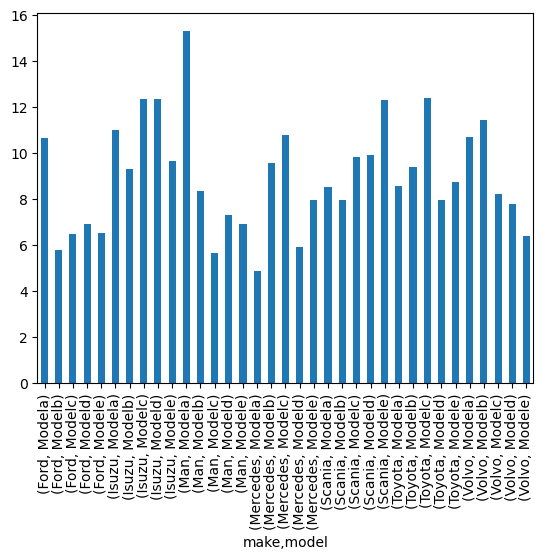

In [13]:
# o	Vehicle performance by make and model

df.groupby(['make','model'])['fuel_efficiency_km_l'].mean().plot(kind='bar')

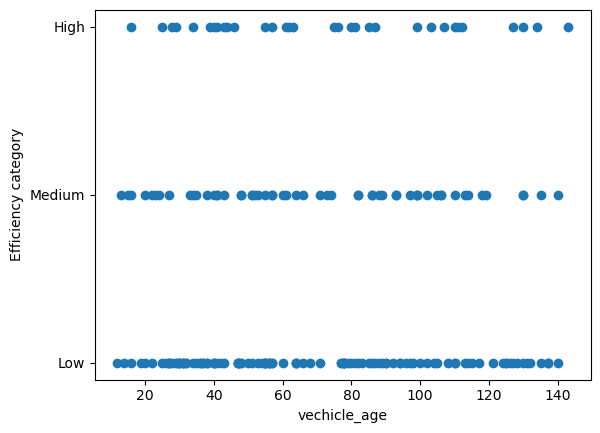

In [14]:
#o	Age vs efficiency correlation analysis
plt.scatter(df['vechicle_age'], df['Efficiency category'])
plt.xlabel("vechicle_age")
plt.ylabel('Efficiency category')
plt.show()
           

<Axes: xlabel='vehicle_type'>

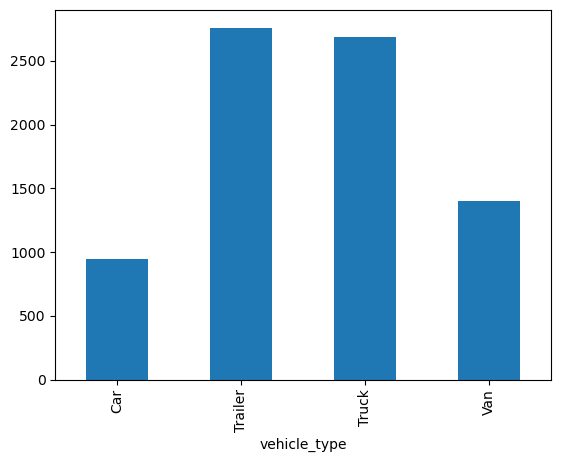

In [15]:
#o	Maintenance cost trends by vehicle type

df.groupby('vehicle_type')['annual_maintenance_cost'].mean().plot(kind='bar')


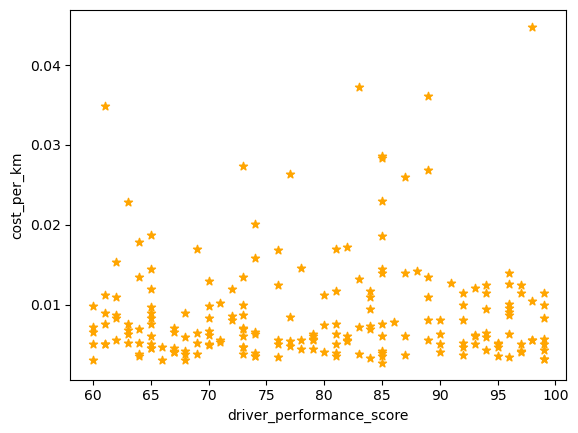

In [16]:
#o	Driver performance impact analysis
plt.scatter(df['driver_performance_score'], df['cost_per_km'],color='orange', marker='*')
plt.xlabel('driver_performance_score')
plt.ylabel('cost_per_km')
plt.show()

In [19]:
df_final = df.copy()
df_final.head()


,vehicle_id,make,model,year,vehicle_type,capacity_kg,purchase_date,current_mileage_km,fuel_efficiency_km_l,annual_maintenance_cost,...,monthly_milegade,vechicle_age_month,monthlt_milegade,Efficiency category,vehicle_age_years,vehicle_age_months,monthly_mileage,efficiency_category,replacement_action,km_per_year
0,Veh1000,Isuzu,Modela,2010,Trailer,13234,2022-06-17,824724,4.4,3154.69,...,1676.2683,492,1676.268293,Low,3.50,42.0,19636.29,Low,Keep,235635.43
1,Veh1001,Volvo,Modele,2017,Van,19290,2018-05-14,312114,8.4,1671.87,...,288.9944,1080,288.994444,Low,7.59,91.1,3426.06,Low,Keep,41112.71
2,Veh1002,Man,Modeld,2023,Van,7254,2023-08-03,69279,8.8,962.02,...,213.8241,324,213.824074,Low,2.37,28.4,2439.40,Low,Keep,29272.82
3,Veh1003,Isuzu,Modeld,2023,Van,18144,2023-12-11,63946,12.5,1085.36,...,231.6884,276,231.688406,Medium,2.01,24.1,2653.36,Medium,Keep,31840.33
4,Veh1004,Toyota,Modeld,2021,Van,8350,2021-04-27,92481,11.0,1039.38,...,140.1227,660,140.122727,Medium,4.64,55.7,1660.34,Medium,Keep,19924.09


In [21]:
df_final.to_csv("Cleaned_Fleet_Data_Professional.csv", index=False)
print("File saved successfully")

File saved successfully
